# 06. v2 피처 효과 측정 + 그룹 3 전이학습

## 이 노트북의 목적 (Phase 4-B)

Phase 4에서 **다중 시간 폴드 교차검증**을 만들었다. 이제 두 가지를 정직하게 잴 수 있다.

1. **`03_features.ipynb` §8-B에서 추가한 v2 피처 21개가 실제로 점수를 올리는가?**
   묶음(결빙 지속성 / 구름·안개 / 복사 안정도 / 풍향 시어)별로 따로 넣어 **무엇이 기여하는지 분리**한다.
2. **그룹 3의 병목을 뚫을 수 있는가?**
   그룹 3은 모든 실험에서 점수가 가장 낮았다(CV 0.57 vs 0.60 / 0.65).
   원인은 명확하다 — **라벨이 2023년부터만 있어 학습 행이 절반(8,760개, 피처당 49행)**이다.

## 왜 지금인가

`reports/phase2_features.md` §4-3에 이렇게 적어 두었다.

> **결정 (2026-07-10)**: 추가 피처 후보들을 지금 넣지 않고, 먼저 Phase 3에서 베이스라인 점수를 확보한다.
> **개선 폭을 잴 기준선이 없으면 어떤 피처가 실제로 기여했는지 알 수 없기 때문**이다.

이제 기준선(Phase 4: CV 0.6059 / 2024 홀드아웃 0.6308)이 있고, 4개 폴드짜리 검증도 있다.
약속대로 **하나씩 넣고 재서** 판단한다.

## 실험 설계 — 무엇을 고정하는가

피처의 효과만 보려면 나머지를 전부 고정해야 한다.

| 고정 조건 | 값 | 근거 |
|---|---|---|
| 학습 방식 | `train_on="all"` + **`actual` 표본 가중** | Phase 4 §2-3 절제 실험 1위 |
| 손실 | 분위수, **그룹별 τ = 0.70 / 0.50 / 0.65** | Phase 4 §2-4 |
| 하이퍼파라미터 | Phase 3·4의 기본값 (튜닝 전) | 튜닝과 피처 효과가 섞이지 않게 |
| 검증 | 2022~2023 rolling-origin 4폴드 | Phase 4 §2-2 |
| 홀드아웃 | 2024 — **최종 확인 한 번만** | CLAUDE.md 4번 |

**τ를 Phase 4 값으로 고정하는 이유**: τ는 이 문제의 가장 큰 지렛대다(+0.03).
피처를 바꾸면서 τ도 같이 바꾸면 **점수가 올라도 무엇 덕분인지 알 수 없다.**

## 0. 준비

In [1]:
import os, random, time, json, subprocess
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import lightgbm as lgb

import sys
sys.path.insert(0, ".")
from src.metric import metric, metric_by_group, group_score, TARGET_COLS, CAPACITY_KWH

plt.rcParams["font.family"] = "Malgun Gothic"
plt.rcParams["axes.unicode_minus"] = False

RNG_SEED = 42
os.environ["PYTHONHASHSEED"] = str(RNG_SEED)
random.seed(RNG_SEED); np.random.seed(RNG_SEED)
N_THREADS = 4

PROCESSED_DIR = Path("data/processed")
FIG_DIR = Path("reports/figures"); FIG_DIR.mkdir(parents=True, exist_ok=True)
EXP_DIR = Path("experiments"); EXP_DIR.mkdir(exist_ok=True)

VAL_START = pd.Timestamp("2024-01-01 01:00:00")
INNER_VAL_START = pd.Timestamp("2023-07-01 01:00:00")
SCORE_THRESHOLD = 0.10
MAX_ROUNDS, EARLY_STOP = 2000, 50

# Phase 4에서 확정한 학습 설정 (여기서는 고정한다)
WEIGHT_BY_ACTUAL = True
GROUP_TAU = {"kpx_group_1": 0.70, "kpx_group_2": 0.50, "kpx_group_3": 0.65}

BASE_PARAMS = dict(learning_rate=0.05, num_leaves=63, min_data_in_leaf=40, feature_fraction=0.7,
                   bagging_fraction=0.8, bagging_freq=1, lambda_l2=1.0, verbosity=-1,
                   seed=RNG_SEED, num_threads=N_THREADS, deterministic=True, force_row_wise=True)

# v2 피처 표와 매니페스트(어떤 컬럼이 어느 묶음인지)를 읽는다
feat = pd.read_parquet(PROCESSED_DIR / "features_v2_train.parquet")
with open(PROCESSED_DIR / "feature_manifest.json", encoding="utf-8") as fp:
    manifest = json.load(fp)

V1 = manifest["v1_features"]
V2_ADDED = manifest["v2_added_features"]
V2_BLOCKS = manifest["v2_blocks"]

dtm = feat["forecast_kst_dtm"]
holdout_mask = dtm >= VAL_START

print(f"v1 {len(V1)}개 + v2 추가 {len(V2_ADDED)}개 = {len(V1)+len(V2_ADDED)}개")
for k, v in V2_BLOCKS.items():
    print(f"  {k:<22}: {len(v):2d}개  {v}")

v1 179개 + v2 추가 21개 = 200개
  icing_persistence     :  6개  ['icing_cum6h', 'icing_cum12h', 'icing_cum24h', 'icing_incloud_cum12h', 'hours_since_icing', 'melt_potential']
  cloud_fog_icing       :  6개  ['lcc', 'mcc', 'hcc', 'vlcdc', 'icing_flag_lit', 'icing_incloud']
  radiation_stability   :  6개  ['ndnsw', 'ndnlw', 'net_radiation', 'is_daytime', 'gfs_r850', 't850_minus_thub']
  veer                  :  3개  ['ldaps_veer_10_50', 'gfs_veer_10_100', 'gfs_veer_100_850']


## 1. 폴드와 학습 함수 (Phase 4와 동일)

`05_tuning.ipynb`와 **완전히 같은 폴드·같은 평가**를 쓴다. 그래야 Phase 4의 숫자와 직접 비교할 수 있다.

In [2]:
FOLDS = [
    ("F1 겨울", pd.Timestamp("2023-01-01 01:00:00"), pd.Timestamp("2023-04-01 00:00:00")),
    ("F2 봄",   pd.Timestamp("2023-04-01 01:00:00"), pd.Timestamp("2023-07-01 00:00:00")),
    ("F3 여름", pd.Timestamp("2023-07-01 01:00:00"), pd.Timestamp("2023-10-01 00:00:00")),
    ("F4 가을", pd.Timestamp("2023-10-01 01:00:00"), pd.Timestamp("2024-01-01 00:00:00")),
]
MIN_TRAIN_ROWS = 1000


def fold_masks(group, fold):
    """확장 윈도: 검증창 직전까지의 라벨 있는 행 전부로 학습한다. 학습 행이 너무 적으면 None."""
    _, vs, ve = fold
    has_label = feat[group].notna()
    train = has_label & (dtm < vs)
    val = (dtm >= vs) & (dtm <= ve)
    return None if int(train.sum()) < MIN_TRAIN_ROWS else (train, val)


def scored(group, mask):
    """마스크 중 채점 대상(실제 이용률 >= 10%)인 행만."""
    return mask & (feat[group] >= CAPACITY_KWH[group] * SCORE_THRESHOLD)


def fit_predict(group, cols, train_mask, val_mask, params, num_boost_round=None):
    """
    한 그룹·한 폴드를 학습하고 검증 구간을 예측한다.
    입력: cols -- 사용할 피처 컬럼 목록 (이 노트북의 실험 변수)
    출력: (예측 배열, 사용한 트리 개수)
    """
    w = feat.loc[train_mask, group].to_numpy() if WEIGHT_BY_ACTUAL else None
    dtr = lgb.Dataset(feat.loc[train_mask, cols], label=feat.loc[train_mask, group], weight=w)

    if num_boost_round is not None:
        booster = lgb.train(params, dtr, num_boost_round=num_boost_round)
        n_used = num_boost_round
    else:
        sv = scored(group, val_mask)   # 조기 종료 기준은 채점 대상 행의 손실
        dva = lgb.Dataset(feat.loc[sv, cols], label=feat.loc[sv, group], reference=dtr)
        booster = lgb.train(params, dtr, num_boost_round=MAX_ROUNDS, valid_sets=[dva],
                            callbacks=[lgb.early_stopping(EARLY_STOP, verbose=False)])
        n_used = booster.best_iteration

    pred = booster.predict(feat.loc[val_mask, cols], num_iteration=n_used)
    return np.clip(pred, 0.0, CAPACITY_KWH[group]), n_used


def cv_group(group, cols):
    """
    그룹 하나의 폴드 평균 group_score. τ는 Phase 4에서 고정한 값을 쓴다.
    출력: (폴드 평균, {폴드이름: 점수})  -- 폴드별 점수를 남겨야 '차이가 잡음인지' 판정할 수 있다.
    """
    params = {**BASE_PARAMS, "objective": "quantile", "alpha": GROUP_TAU[group]}
    per_fold = {}
    for fold in FOLDS:
        m = fold_masks(group, fold)
        if m is None:
            continue
        tr_m, va_m = m
        pred, _ = fit_predict(group, cols, tr_m, va_m, params)
        s, _, _ = group_score(feat.loc[va_m, group].to_numpy(), pred, CAPACITY_KWH[group])
        per_fold[fold[0]] = s
    return float(np.mean(list(per_fold.values()))), per_fold


def cv_all(cols):
    """세 그룹의 폴드 평균 점수, 그 평균(= 추정 total_score), 그리고 (그룹,폴드)별 원점수."""
    per, detail = {}, {}
    for g in TARGET_COLS:
        per[g], detail[g] = cv_group(g, cols)
    return float(np.mean(list(per.values()))), per, detail


print("준비 완료")

준비 완료


## 2. 실험 1 — v2 피처 묶음별 효과 측정

**한 묶음씩 v1에 더해서** 잰다. 전부 한꺼번에 넣고 "좋아졌다"고 하면 무엇 덕분인지 모른다.

| 묶음 | 피처 | 기대 |
|---|---|---|
| `icing_persistence` | 누적 착빙, 경과 시간, 해빙 | 얼음은 조건이 끝난 뒤에도 남는다 |
| `cloud_fog_icing` | 구름·안개, 문헌 임계값 착빙 | 착빙은 구름 속에서 일어난다 |
| `radiation_stability` | 순복사, 주야, 850hPa 역전 | 야간 복사냉각 → 안정 경계층 |
| `veer` | 높이별 풍향 변화 | 문헌상 2차 효과 |

**미리 경계할 것 — 상관표의 함정.** `03_features.ipynb` §8-B-2에서 `hours_since_icing`의 상관이 −0.22,
`icing_flag_lit`이 +0.15로 꽤 높게 나왔다. **그런데 이것은 결빙 신호가 아니라 계절 프록시다.**
착빙 조건은 겨울에만 생기고, 겨울은 바람이 세서 발전량이 높다. 여름엔 착빙이 아예 없어
`hours_since_icing`이 상한(72)에 붙고 발전량은 낮다. 그래서 상관이 크게 나온다.

이미 모델에는 `month_sin/cos`, `doy_sin/cos` 같은 계절 피처가 있으므로,
**결빙 피처가 계절 정보 이상을 주는지**는 오직 교차검증 점수 변화로만 알 수 있다.

In [3]:
t0 = time.time()
ablation, cv_detail = {}, {}

configs = [("v1 (기준선, 179개)", V1)]
configs += [(f"v1 + {name}", V1 + block) for name, block in V2_BLOCKS.items()]
configs += [("v2 전체 (200개)", V1 + V2_ADDED)]

for name, cols in configs:
    total, per, detail = cv_all(cols)
    ablation[name] = {"cv_total": total, **{f"g{g[-1]}": v for g, v in per.items()}, "n_feat": len(cols)}
    cv_detail[name] = detail

base = ablation["v1 (기준선, 179개)"]["cv_total"]
for name in ablation:
    r = ablation[name]
    print(f"{name:<28}: CV {r['cv_total']:.4f} ({r['cv_total']-base:+.4f}) | "
          f"g1 {r['g1']:.4f} g2 {r['g2']:.4f} g3 {r['g3']:.4f}")
print(f"\n({time.time()-t0:.0f}초)")

ab_df = pd.DataFrame(ablation).T.sort_values("cv_total", ascending=False)
ab_df["Δ vs v1"] = ab_df["cv_total"] - base
print("\n[v2 피처 묶음별 효과 — CV 4폴드 평균]")
print(ab_df[["cv_total", "Δ vs v1", "g1", "g2", "g3", "n_feat"]].to_string(float_format=lambda x: f"{x:.4f}"))

v1 (기준선, 179개)              : CV 0.6059 (+0.0000) | g1 0.6030 g2 0.6456 g3 0.5692
v1 + icing_persistence      : CV 0.6027 (-0.0032) | g1 0.5992 g2 0.6408 g3 0.5681
v1 + cloud_fog_icing        : CV 0.6024 (-0.0035) | g1 0.5996 g2 0.6415 g3 0.5660
v1 + radiation_stability    : CV 0.6048 (-0.0012) | g1 0.6028 g2 0.6415 g3 0.5700
v1 + veer                   : CV 0.6032 (-0.0027) | g1 0.5995 g2 0.6451 g3 0.5650
v2 전체 (200개)                : CV 0.6001 (-0.0058) | g1 0.5987 g2 0.6424 g3 0.5592

(100초)

[v2 피처 묶음별 효과 — CV 4폴드 평균]
                          cv_total  Δ vs v1     g1     g2     g3   n_feat
v1 (기준선, 179개)              0.6059   0.0000 0.6030 0.6456 0.5692 179.0000
v1 + radiation_stability    0.6048  -0.0012 0.6028 0.6415 0.5700 185.0000
v1 + veer                   0.6032  -0.0027 0.5995 0.6451 0.5650 182.0000
v1 + icing_persistence      0.6027  -0.0032 0.5992 0.6408 0.5681 185.0000
v1 + cloud_fog_icing        0.6024  -0.0035 0.5996 0.6415 0.5660 185.0000
v2 전체 (200개)                

### 2-1. 이 차이는 잡음인가 — 폴드별 짝비교

CV 평균 하나만 보고 "나빠졌다"고 하면 안 된다. 폴드가 4개뿐이라 **평균 자체에 흔들림이 있다.**
(Phase 4 §3-3에서 홀드아웃 점수의 표본오차가 ±0.005였다. CV는 표본이 더 작으니 더 흔들린다.)

**짝비교(paired comparison)** 를 한다. 같은 (그룹, 폴드) 조합에서 v1과 비교하면
"그 폴드가 원래 쉬웠나/어려웠나"가 상쇄되고 **피처 효과만 남는다.**

- 11개 짝 (그룹 1·2는 4폴드, 그룹 3은 3폴드)
- 개선된 짝의 개수와 평균 차이를 함께 본다. **11개 중 6개만 개선됐다면 동전던지기와 다를 바 없다.**

In [4]:
def paired_deltas(name):
    """v1 대비 (그룹, 폴드)별 점수 차이를 모은다."""
    d = []
    for g in TARGET_COLS:
        for f, s in cv_detail[name][g].items():
            d.append({"그룹": g[-1], "폴드": f, "delta": s - cv_detail["v1 (기준선, 179개)"][g][f]})
    return pd.DataFrame(d)


rows = []
for name in ablation:
    if name.startswith("v1 (기준선"):
        continue
    d = paired_deltas(name)["delta"]
    rows.append({
        "설정": name, "평균 Δ": d.mean(), "표준편차": d.std(),
        "개선된 짝": f"{(d > 0).sum()}/{len(d)}",
        "평균/표준오차": d.mean() / (d.std() / np.sqrt(len(d))),
    })
paired_df = pd.DataFrame(rows)
print("[v1 대비 짝비교 — 11개 (그룹×폴드) 짝]")
print(paired_df.to_string(index=False, float_format=lambda x: f"{x:+.4f}"))
print("\n'평균/표준오차'의 절댓값이 2보다 크면 우연으로 보기 어렵다(대략 95% 기준).")
print("개선된 짝이 절반 근처(5~6/11)면 방향성이 없다는 뜻이다.")

[v1 대비 짝비교 — 11개 (그룹×폴드) 짝]
                      설정    평균 Δ    표준편차 개선된 짝  평균/표준오차
  v1 + icing_persistence -0.0034 +0.0067  4/11  -1.6973
    v1 + cloud_fog_icing -0.0036 +0.0046  3/11  -2.5681
v1 + radiation_stability -0.0013 +0.0051  3/11  -0.8703
               v1 + veer -0.0026 +0.0064  5/11  -1.3364
            v2 전체 (200개) -0.0055 +0.0063  2/11  -2.8811

'평균/표준오차'의 절댓값이 2보다 크면 우연으로 보기 어렵다(대략 95% 기준).
개선된 짝이 절반 근처(5~6/11)면 방향성이 없다는 뜻이다.


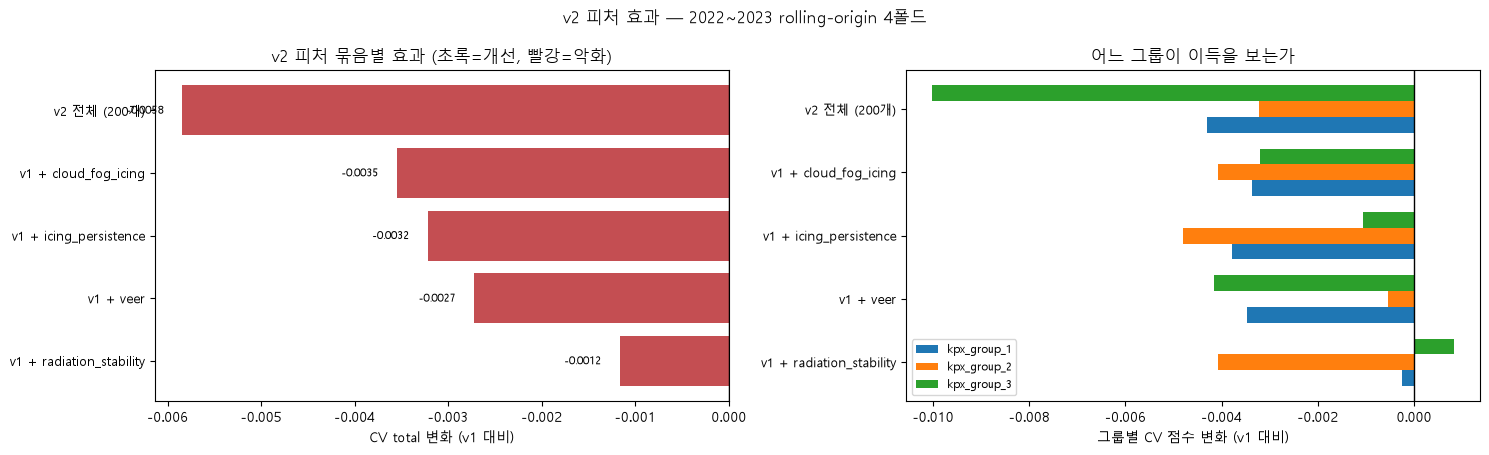

In [5]:
# 그림: 묶음별 CV 변화 (그룹별 분해)
plot = ab_df.drop(index=["v1 (기준선, 179개)"])
fig, axes = plt.subplots(1, 2, figsize=(15, 4.6))

y = np.arange(len(plot))
colors = ["#55A868" if d > 0 else "#C44E52" for d in plot["Δ vs v1"]]
axes[0].barh(y, plot["Δ vs v1"], color=colors)
axes[0].axvline(0, color="black", lw=1)
axes[0].set_yticks(y); axes[0].set_yticklabels(plot.index, fontsize=9)
axes[0].set_xlabel("CV total 변화 (v1 대비)")
axes[0].set_title("v2 피처 묶음별 효과 (초록=개선, 빨강=악화)")
for i, v in enumerate(plot["Δ vs v1"]):
    axes[0].text(v + (0.0002 if v >= 0 else -0.0002), i, f"{v:+.4f}", va="center",
                 ha="left" if v >= 0 else "right", fontsize=8)

w = 0.25
for i, gi in enumerate([1, 2, 3]):
    delta = plot[f"g{gi}"] - ablation["v1 (기준선, 179개)"][f"g{gi}"]
    axes[1].barh(y + (i - 1) * w, delta, height=w, label=f"kpx_group_{gi}")
axes[1].axvline(0, color="black", lw=1)
axes[1].set_yticks(y); axes[1].set_yticklabels(plot.index, fontsize=9)
axes[1].set_xlabel("그룹별 CV 점수 변화 (v1 대비)")
axes[1].legend(fontsize=8); axes[1].set_title("어느 그룹이 이득을 보는가")

fig.suptitle("v2 피처 효과 — 2022~2023 rolling-origin 4폴드")
fig.tight_layout(); fig.savefig(FIG_DIR / "phase4b_feature_ablation.png", dpi=120); plt.show()

### 2-2. 겨울에만 따로 재 본다

결빙 피처는 **겨울의 일부 시간에만** 작동한다. 1년 평균 점수에 묻혀 보이지 않을 수 있다.
겨울 폴드(F1: 2023-01~03)만 떼어 보면 효과가 드러날 수 있다.

**주의**: 폴드 하나(3개월)의 점수는 표본이 작아 잡음이 크다. **방향만 참고**하고 결론은 4폴드 평균으로 낸다.

In [6]:
winter_fold = FOLDS[0]   # F1 겨울 (2023-01~03)
rows = []
for name, cols in [("v1", V1), ("v1 + icing_persistence", V1 + V2_BLOCKS["icing_persistence"]),
                   ("v1 + cloud_fog_icing", V1 + V2_BLOCKS["cloud_fog_icing"]),
                   ("v2 전체", V1 + V2_ADDED)]:
    r = {"설정": name}
    for g in TARGET_COLS:
        m = fold_masks(g, winter_fold)
        if m is None:
            r[f"g{g[-1]}"] = np.nan
            continue
        tr_m, va_m = m
        params = {**BASE_PARAMS, "objective": "quantile", "alpha": GROUP_TAU[g]}
        pred, _ = fit_predict(g, cols, tr_m, va_m, params)
        r[f"g{g[-1]}"], _, _ = group_score(feat.loc[va_m, g].to_numpy(), pred, CAPACITY_KWH[g])
    rows.append(r)

winter_df = pd.DataFrame(rows).set_index("설정")
print("[겨울 폴드(2023-01~03)만 — 그룹 3은 학습 라벨이 없어 NaN]")
print(winter_df.to_string(float_format=lambda x: f"{x:.4f}"))
print("\nv1 대비 변화:")
print((winter_df - winter_df.loc["v1"]).to_string(float_format=lambda x: f"{x:+.4f}"))

[겨울 폴드(2023-01~03)만 — 그룹 3은 학습 라벨이 없어 NaN]
                           g1     g2  g3
설정                                      
v1                     0.5840 0.6303 NaN
v1 + icing_persistence 0.5864 0.6349 NaN
v1 + cloud_fog_icing   0.5822 0.6323 NaN
v2 전체                  0.5841 0.6331 NaN

v1 대비 변화:
                            g1      g2  g3
설정                                        
v1                     +0.0000 +0.0000 NaN
v1 + icing_persistence +0.0024 +0.0046 NaN
v1 + cloud_fog_icing   -0.0019 +0.0019 NaN
v2 전체                  +0.0001 +0.0028 NaN


### 2-3. 모델이 v2 피처를 쓰기는 하는가 — 중요도로 진단을 가른다

CV 점수가 안 올랐다고 해서 원인이 하나인 것은 아니다. **두 가지 전혀 다른 진단이 가능하다.**

| 관측 | 진단 | 대응 |
|---|---|---|
| 모델이 v2 피처를 **거의 안 쓴다** | 정보 자체가 없다 | 버린다 |
| 모델이 v2 피처를 **많이 쓰는데도** 점수가 안 오른다 | 정보는 있으나 **기존 피처와 겹치거나, 늘어난 피처 수가 학습을 방해**한다 | 골라서 넣거나, 다른 방식으로 쓴다 |

`feature_fraction=0.7`이라 트리를 만들 때마다 피처의 70%만 후보로 뽑는다.
쓸모없는 피처가 21개 늘면 **매 분기마다 좋은 피처가 후보에서 빠질 확률이 커진다.** 이것을 "희석"이라 부른다.

In [7]:
imp_rows = []
for g in TARGET_COLS:
    params = {**BASE_PARAMS, "objective": "quantile", "alpha": GROUP_TAU[g]}
    has_label = feat[g].notna()
    fit_all = has_label & (dtm < VAL_START)
    w = feat.loc[fit_all, g].to_numpy() if WEIGHT_BY_ACTUAL else None
    b = lgb.train(params, lgb.Dataset(feat.loc[fit_all, V1 + V2_ADDED], label=feat.loc[fit_all, g], weight=w),
                  num_boost_round=400)
    imp = pd.Series(b.feature_importance(importance_type="gain"), index=b.feature_name())
    imp_rows.append((imp / imp.sum()).rename(g))

imp_tbl = pd.concat(imp_rows, axis=1)
imp_tbl["평균"] = imp_tbl.mean(axis=1)
v2_imp = imp_tbl.loc[V2_ADDED].sort_values("평균", ascending=False)

print("[v2 피처의 gain 중요도 (전체 합=1)]")
print(v2_imp.to_string(float_format=lambda x: f"{x:.4f}"))
uniform = 1.0 / len(imp_tbl)
print(f"\nv2 피처 {len(V2_ADDED)}개의 중요도 합: {v2_imp['평균'].sum()*100:.2f}%")
print(f"균등하게 나눈다면 {len(V2_ADDED)*uniform*100:.2f}% -> 비슷하면 '평균적인 피처만큼은 쓰인다'는 뜻")

print("\n[전체 상위 15개 — v2 피처는 ★]")
for name, r in imp_tbl.sort_values("평균", ascending=False).head(15).iterrows():
    print(f"  {'★' if name in V2_ADDED else ' '} {name:<34} {r['평균']:.4f}")

TOP_V2 = v2_imp.index[0]
print(f"\nv2 중 가장 많이 쓰인 피처: {TOP_V2} (평균 {v2_imp.loc[TOP_V2, '평균']:.4f})")

[v2 피처의 gain 중요도 (전체 합=1)]
                      kpx_group_1  kpx_group_2  kpx_group_3     평균
t850_minus_thub            0.0253       0.0180       0.0126 0.0186
gfs_r850                   0.0104       0.0090       0.0099 0.0098
icing_cum24h               0.0096       0.0094       0.0075 0.0089
ndnlw                      0.0084       0.0082       0.0088 0.0085
gfs_veer_10_100            0.0092       0.0064       0.0084 0.0080
ldaps_veer_10_50           0.0068       0.0077       0.0092 0.0079
net_radiation              0.0069       0.0059       0.0082 0.0070
gfs_veer_100_850           0.0064       0.0069       0.0074 0.0069
icing_cum12h               0.0069       0.0055       0.0060 0.0061
melt_potential             0.0046       0.0050       0.0032 0.0043
hours_since_icing          0.0045       0.0044       0.0038 0.0042
lcc                        0.0036       0.0049       0.0037 0.0041
icing_cum6h                0.0048       0.0041       0.0030 0.0040
ndnsw                      0.0029  

### 2-4. 희석 가설 검증 — v2 피처를 **딱 하나만** 넣어 본다

중요도가 높은데도 묶음으로 넣으면 점수가 떨어진다면, 원인은 **"쓸모없는 피처가 같이 들어와 희석시킨다"** 일 수 있다.
가장 많이 쓰인 v2 피처 **하나만** 넣어 보면 이 가설을 검증할 수 있다.

- **하나만 넣었을 때 좋아진다** → 희석이 원인. 피처 선택으로 건질 수 있다.
- **하나만 넣어도 나빠진다** → 그 정보는 이미 v1에 들어 있다. v2를 통째로 버린다.

In [8]:
total_single, per_single, detail_single = cv_all(V1 + [TOP_V2])
ablation[f"v1 + {TOP_V2} (1개만)"] = {"cv_total": total_single,
                                      **{f"g{g[-1]}": v for g, v in per_single.items()},
                                      "n_feat": len(V1) + 1}
cv_detail[f"v1 + {TOP_V2} (1개만)"] = detail_single

d = paired_deltas(f"v1 + {TOP_V2} (1개만)")["delta"]
print(f"v1 + {TOP_V2} (1개만): CV {total_single:.4f} ({total_single - base:+.4f})")
print(f"  짝비교: 평균 Δ {d.mean():+.4f}, 개선된 짝 {(d>0).sum()}/{len(d)}, 평균/표준오차 {d.mean()/(d.std()/np.sqrt(len(d))):+.2f}")
print(f"\n비교) v1 + radiation_stability(6개 묶음): {ablation['v1 + radiation_stability']['cv_total'] - base:+.4f}")
print(f"      v2 전체(21개)                  : {ablation['v2 전체 (200개)']['cv_total'] - base:+.4f}")

ab_df = pd.DataFrame(ablation).T.sort_values("cv_total", ascending=False)
ab_df["Δ vs v1"] = ab_df["cv_total"] - base
print("\n[최종 정리]")
print(ab_df[["cv_total", "Δ vs v1", "g1", "g2", "g3", "n_feat"]].to_string(float_format=lambda x: f"{x:.4f}"))

v1 + t850_minus_thub (1개만): CV 0.6031 (-0.0028)
  짝비교: 평균 Δ -0.0026, 개선된 짝 4/11, 평균/표준오차 -1.44

비교) v1 + radiation_stability(6개 묶음): -0.0012
      v2 전체(21개)                  : -0.0058

[최종 정리]
                            cv_total  Δ vs v1     g1     g2     g3   n_feat
v1 (기준선, 179개)                0.6059   0.0000 0.6030 0.6456 0.5692 179.0000
v1 + radiation_stability      0.6048  -0.0012 0.6028 0.6415 0.5700 185.0000
v1 + veer                     0.6032  -0.0027 0.5995 0.6451 0.5650 182.0000
v1 + t850_minus_thub (1개만)    0.6031  -0.0028 0.6044 0.6414 0.5635 180.0000
v1 + icing_persistence        0.6027  -0.0032 0.5992 0.6408 0.5681 185.0000
v1 + cloud_fog_icing          0.6024  -0.0035 0.5996 0.6415 0.5660 185.0000
v2 전체 (200개)                  0.6001  -0.0058 0.5987 0.6424 0.5592 200.0000


## 3. 실험 2 — 그룹 3 전이학습

### 3-1. 문제 정의

| 그룹 | 학습 라벨 (2022~23) | 피처당 행 수 | CV 점수 (Phase 4) |
|---|---:|---:|---:|
| kpx_group_1 | 17,422 | 97 | 0.6030 |
| kpx_group_2 | 17,423 | 97 | 0.6456 |
| **kpx_group_3** | **8,760** | **49** | **0.5692** |

그룹 3만 라벨이 2023년부터다. 게다가 기종이 다르다(UNISON U136, 5기, 21.0MW).
**하지만 세 그룹은 같은 산등성이에 있고 라벨 상관이 0.90~0.93이다.**
그룹 1·2의 17,000시간을 그룹 3 학습에 끌어올 수 있다면 데이터가 3배가 된다.

### 3-2. 세 가지 방법을 비교한다

| 방법 | 어떻게 | 왜 될 것 같은가 |
|---|---|---|
| **(a) 기준선** | 그룹 3 라벨만으로 학습 | 현재 방식 |
| **(b) 멀티태스크** | 세 그룹의 행을 **모두 쌓아** 하나의 모델로 학습.<br>타깃은 **이용률**(발전량/설비용량), 그룹 표시 컬럼 3개 추가 | 설비용량이 달라도 이용률로 바꾸면 같은 축에서 비교된다.<br>그룹 표시로 모델이 그룹별 차이를 배운다 |
| **(c) 사전학습 + 파인튜닝** | 그룹 1·2로 먼저 학습한 뒤,<br>그 모델을 **출발점으로 삼아** 그룹 3으로 이어서 학습 | 바람→출력의 일반 관계를 먼저 배우고,<br>그룹 3의 고유한 특성만 마지막에 조정 |

**타깃을 이용률로 바꾸는 이유**: 그룹 1·2는 21,600kWh, 그룹 3은 21,000kWh가 만점이다.
kWh 그대로 쌓으면 모델이 "그룹 3은 원래 조금 덜 나온다"를 용량 차이인지 성능 차이인지 구분 못 한다.
**설비용량으로 나눠 0~1로 맞추면** 세 그룹이 같은 척도가 된다. 예측 후 다시 21,000을 곱한다.

**누수 검토**: 그룹 1·2의 **라벨**을 그룹 3 모델 학습에 쓴다. 이 라벨은 전부 **학습 기간(train)** 의 것이고,
test 기간에는 어느 그룹의 라벨도 존재하지 않는다. 폴드 규칙(검증창 이전 데이터만)도 세 그룹 모두에 똑같이 적용한다.
따라서 CLAUDE.md 4번 위반이 아니다.

In [9]:
GROUP_ORDER = {g: i for i, g in enumerate(TARGET_COLS)}


def build_stacked(cols, groups, row_mask_fn):
    """
    여러 그룹의 행을 세로로 쌓아 하나의 학습 집합을 만든다 (멀티태스크용).

    입력:
        cols        : 사용할 피처 컬럼
        groups      : 쌓을 그룹 목록
        row_mask_fn : group -> boolean mask (그 그룹에서 쓸 행)
    출력:
        (X, y_cf, weight, ) -- X에는 그룹 표시 컬럼 3개가 추가된다.
        y_cf   : 이용률 (발전량 / 설비용량), 0~1
        weight : 실제 발전량[kWh]. FICR이 actual 가중이므로 그대로 쓴다.
    """
    Xs, ys, ws = [], [], []
    for g in groups:
        m = row_mask_fn(g)
        X = feat.loc[m, cols].copy()
        for gg in TARGET_COLS:                       # 그룹 표시(one-hot)
            X[f"is_{gg}"] = 1.0 if gg == g else 0.0
        Xs.append(X)
        ys.append(feat.loc[m, g].to_numpy() / CAPACITY_KWH[g])
        ws.append(feat.loc[m, g].to_numpy())
    return pd.concat(Xs, ignore_index=True), np.concatenate(ys), np.concatenate(ws)


def predict_stacked(booster, cols, target_group, val_mask, n_iter=None):
    """멀티태스크 모델로 특정 그룹의 예측을 만든다 (그룹 표시를 그 그룹으로 세팅)."""
    X = feat.loc[val_mask, cols].copy()
    for gg in TARGET_COLS:
        X[f"is_{gg}"] = 1.0 if gg == target_group else 0.0
    cf = booster.predict(X, num_iteration=n_iter)
    return np.clip(cf * CAPACITY_KWH[target_group], 0.0, CAPACITY_KWH[target_group])


def cv_group3_baseline(cols):
    """(a) 그룹 3 라벨만으로 학습."""
    return cv_group("kpx_group_3", cols)[0]


def cv_group3_multitask(cols):
    """(b) 세 그룹의 행을 모두 쌓아 하나의 모델로 학습하고, 그룹 3을 예측한다."""
    g3 = "kpx_group_3"
    params = {**BASE_PARAMS, "objective": "quantile", "alpha": GROUP_TAU[g3]}
    scores = []
    for fold in FOLDS:
        m3 = fold_masks(g3, fold)
        if m3 is None:
            continue
        _, va_m = m3
        _, vs, _ = fold

        def rows(g):   # 각 그룹에서 '검증창 이전 + 라벨 있는' 행만 (폴드 규칙 동일 적용)
            return feat[g].notna() & (dtm < vs)

        X, y_cf, w = build_stacked(cols, TARGET_COLS, rows)
        Xv, yv_cf, wv = build_stacked(cols, [g3], lambda g: scored(g, va_m))
        dtr = lgb.Dataset(X, label=y_cf, weight=(w if WEIGHT_BY_ACTUAL else None))
        dva = lgb.Dataset(Xv, label=yv_cf, reference=dtr)
        booster = lgb.train(params, dtr, MAX_ROUNDS, valid_sets=[dva],
                            callbacks=[lgb.early_stopping(EARLY_STOP, verbose=False)])

        pred = predict_stacked(booster, cols, g3, va_m, booster.best_iteration)
        s, _, _ = group_score(feat.loc[va_m, g3].to_numpy(), pred, CAPACITY_KWH[g3])
        scores.append(s)
    return float(np.mean(scores))


def cv_group3_finetune(cols):
    """
    (c) 그룹 1·2로 사전학습한 뒤 그 모델을 출발점으로 그룹 3을 이어서 학습한다.
    LightGBM의 init_model은 '이미 만든 트리들 위에 트리를 더 쌓는다'는 뜻이다.
    """
    g3 = "kpx_group_3"
    params = {**BASE_PARAMS, "objective": "quantile", "alpha": GROUP_TAU[g3]}
    scores = []
    for fold in FOLDS:
        m3 = fold_masks(g3, fold)
        if m3 is None:
            continue
        _, va_m = m3
        _, vs, _ = fold

        def rows(g):
            return feat[g].notna() & (dtm < vs)

        # 1단계: 그룹 1·2로 사전학습 (이용률 타깃)
        Xp, yp, wp = build_stacked(cols, ["kpx_group_1", "kpx_group_2"], rows)
        pre = lgb.train(params, lgb.Dataset(Xp, label=yp, weight=(wp if WEIGHT_BY_ACTUAL else None)),
                        num_boost_round=300)

        # 2단계: 그룹 3으로 이어서 학습 (사전학습 모델을 출발점으로)
        X3, y3, w3 = build_stacked(cols, [g3], rows)
        Xv, yv, _ = build_stacked(cols, [g3], lambda g: scored(g, va_m))
        dtr3 = lgb.Dataset(X3, label=y3, weight=(w3 if WEIGHT_BY_ACTUAL else None))
        dva3 = lgb.Dataset(Xv, label=yv, reference=dtr3)
        fine = lgb.train(params, dtr3, MAX_ROUNDS, valid_sets=[dva3], init_model=pre,
                         callbacks=[lgb.early_stopping(EARLY_STOP, verbose=False)])

        pred = predict_stacked(fine, cols, g3, va_m, fine.best_iteration)
        s, _, _ = group_score(feat.loc[va_m, g3].to_numpy(), pred, CAPACITY_KWH[g3])
        scores.append(s)
    return float(np.mean(scores))


print("전이학습 함수 준비 완료")

전이학습 함수 준비 완료


In [10]:
# 실험 1에서 가장 좋았던 피처 집합으로 전이학습을 실험한다.
# 설정 이름 -> 컬럼 목록 매핑을 명시적으로 만들어 둔다 (이름 파싱으로 추측하지 않는다).
COLS_BY_NAME = {name: cols for name, cols in configs}
COLS_BY_NAME[f"v1 + {TOP_V2} (1개만)"] = V1 + [TOP_V2]

best_feat_name = ab_df.index[0]
BEST_COLS = COLS_BY_NAME[best_feat_name]
print(f"전이학습에 쓸 피처 집합: {best_feat_name} ({len(BEST_COLS)}개)\n")

t0 = time.time()
transfer = {}
transfer["(a) 그룹3 단독 학습"] = cv_group3_baseline(BEST_COLS)
print(f"(a) 그룹3 단독 학습        : CV {transfer['(a) 그룹3 단독 학습']:.4f}")
transfer["(b) 멀티태스크(3그룹 쌓기)"] = cv_group3_multitask(BEST_COLS)
print(f"(b) 멀티태스크(3그룹 쌓기)  : CV {transfer['(b) 멀티태스크(3그룹 쌓기)']:.4f}")
transfer["(c) 사전학습+파인튜닝"] = cv_group3_finetune(BEST_COLS)
print(f"(c) 사전학습+파인튜닝      : CV {transfer['(c) 사전학습+파인튜닝']:.4f}")

tr_df = pd.Series(transfer).sort_values(ascending=False).to_frame("CV (그룹3, 3폴드 평균)")
tr_df["Δ vs 단독"] = tr_df["CV (그룹3, 3폴드 평균)"] - transfer["(a) 그룹3 단독 학습"]
print(f"\n{tr_df.to_string(float_format=lambda x: f'{x:+.4f}')}")
print(f"\n({time.time()-t0:.0f}초)")

전이학습에 쓸 피처 집합: v1 (기준선, 179개) (179개)



(a) 그룹3 단독 학습        : CV 0.5692


(b) 멀티태스크(3그룹 쌓기)  : CV 0.5677


(c) 사전학습+파인튜닝      : CV 0.5696

                   CV (그룹3, 3폴드 평균)  Δ vs 단독
(c) 사전학습+파인튜닝               +0.5696  +0.0004
(a) 그룹3 단독 학습               +0.5692  +0.0000
(b) 멀티태스크(3그룹 쌓기)           +0.5677  -0.0015

(22초)


## 4. 최종 확인 — 2024 홀드아웃에 한 번

CV에서 고른 조합(피처 집합 + 그룹 3 학습 방식)을 2024에 딱 한 번 적용한다.
`05_tuning.ipynb`와 **똑같은 방식**으로 최종 모델을 만든다:
내부검증(2023-07~12)으로 트리 개수를 정하고, 데이터가 늘어난 비율만큼 키워 2022~2023 전체로 재학습.

In [11]:
def fit_final(group, cols, params):
    """2022~2023 전체로 학습해 2024를 예측한다 (05_tuning.ipynb과 동일한 절차)."""
    has_label = feat[group].notna()
    inner_tr = has_label & (dtm < INNER_VAL_START)
    inner_va = has_label & (dtm >= INNER_VAL_START) & (dtm < VAL_START)
    fit_all = has_label & (dtm < VAL_START)

    _, best_iter = fit_predict(group, cols, inner_tr, inner_va, params)
    n_final = max(int(best_iter * fit_all.sum() / max(inner_tr.sum(), 1)), 50)
    pred, _ = fit_predict(group, cols, fit_all, holdout_mask, params, num_boost_round=n_final)
    return pred


def fit_final_multitask(target_group, cols):
    """멀티태스크 최종 모델: 세 그룹을 쌓아 학습하고 target_group을 예측한다."""
    params = {**BASE_PARAMS, "objective": "quantile", "alpha": GROUP_TAU[target_group]}

    def rows_inner(g):
        return feat[g].notna() & (dtm < INNER_VAL_START)

    def rows_full(g):
        return feat[g].notna() & (dtm < VAL_START)

    inner_va = feat[target_group].notna() & (dtm >= INNER_VAL_START) & (dtm < VAL_START)
    Xi, yi, wi = build_stacked(cols, TARGET_COLS, rows_inner)
    Xv, yv, _ = build_stacked(cols, [target_group], lambda g: scored(g, inner_va))
    dtr = lgb.Dataset(Xi, label=yi, weight=(wi if WEIGHT_BY_ACTUAL else None))
    dva = lgb.Dataset(Xv, label=yv, reference=dtr)
    b = lgb.train(params, dtr, MAX_ROUNDS, valid_sets=[dva],
                  callbacks=[lgb.early_stopping(EARLY_STOP, verbose=False)])

    Xf, yf, wf = build_stacked(cols, TARGET_COLS, rows_full)
    n_final = max(int(b.best_iteration * len(Xf) / len(Xi)), 50)
    final = lgb.train(params, lgb.Dataset(Xf, label=yf, weight=(wf if WEIGHT_BY_ACTUAL else None)),
                      num_boost_round=n_final)
    return predict_stacked(final, cols, target_group, holdout_mask)


def fit_final_finetune(target_group, cols):
    """
    사전학습 + 파인튜닝 최종 모델: 그룹 1·2로 먼저 학습한 뒤 그 위에 그룹 3 트리를 이어 쌓는다.

    주의: 이 함수를 빼먹고 fit_final()로 떨어뜨리면 '파인튜닝을 했다'고 보고하면서
          실제로는 단독 학습 결과를 보고하게 된다. (처음 실행 때 실제로 그 버그가 있었다.)
    """
    params = {**BASE_PARAMS, "objective": "quantile", "alpha": GROUP_TAU[target_group]}

    def rows_inner(g):
        return feat[g].notna() & (dtm < INNER_VAL_START)

    def rows_full(g):
        return feat[g].notna() & (dtm < VAL_START)

    others = [g for g in TARGET_COLS if g != target_group]
    inner_va = feat[target_group].notna() & (dtm >= INNER_VAL_START) & (dtm < VAL_START)

    # 1단계(내부검증용): 다른 그룹으로 사전학습 -> 대상 그룹으로 이어 학습 -> 트리 개수 결정
    Xp, yp, wp = build_stacked(cols, others, rows_inner)
    pre_i = lgb.train(params, lgb.Dataset(Xp, label=yp, weight=(wp if WEIGHT_BY_ACTUAL else None)),
                      num_boost_round=300)
    Xi, yi, wi = build_stacked(cols, [target_group], rows_inner)
    Xv, yv, _ = build_stacked(cols, [target_group], lambda g: scored(g, inner_va))
    dtr = lgb.Dataset(Xi, label=yi, weight=(wi if WEIGHT_BY_ACTUAL else None))
    dva = lgb.Dataset(Xv, label=yv, reference=dtr)
    b = lgb.train(params, dtr, MAX_ROUNDS, valid_sets=[dva], init_model=pre_i,
                  callbacks=[lgb.early_stopping(EARLY_STOP, verbose=False)])
    # init_model이 있을 때 best_iteration이 '이번 학습의 반복 수'인지 '전체 트리 수'인지
    # LightGBM 버전에 따라 다를 수 있으므로, 둘 다 안전하게 처리한다.
    n_pre = pre_i.num_trees()
    bi = b.best_iteration
    added = max((bi - n_pre) if bi > n_pre else bi, 50)

    # 2단계(최종): 2022~2023 전체로 같은 절차를 반복
    Xp, yp, wp = build_stacked(cols, others, rows_full)
    pre_f = lgb.train(params, lgb.Dataset(Xp, label=yp, weight=(wp if WEIGHT_BY_ACTUAL else None)),
                      num_boost_round=300)
    Xf, yf, wf = build_stacked(cols, [target_group], rows_full)
    n_added = max(int(added * len(Xf) / max(len(Xi), 1)), 50)
    final = lgb.train(params, lgb.Dataset(Xf, label=yf, weight=(wf if WEIGHT_BY_ACTUAL else None)),
                      num_boost_round=n_added, init_model=pre_f)
    return predict_stacked(final, cols, target_group, holdout_mask)


def evaluate(preds):
    ans = feat.loc[holdout_mask, TARGET_COLS].reset_index(drop=True)
    pdf = pd.DataFrame({g: np.clip(preds[g], 0, CAPACITY_KWH[g]) for g in TARGET_COLS})
    total, omn, ficr = metric(ans, pdf)
    bg = metric_by_group(ans, pdf)
    out = {"total_score": total, "one_minus_nmae": omn, "ficr": ficr}
    for g in TARGET_COLS:
        out[f"nmae_{g[-1]}"] = bg[g]["nmae"]; out[f"ficr_{g[-1]}"] = bg[g]["ficr"]
    return out


t0 = time.time()
final = {}

# 기준: Phase 4 최종 설정 (v1 피처, 그룹별 tau, actual 가중)
final["phase4_v1"] = evaluate({g: fit_final(g, V1, {**BASE_PARAMS, "objective": "quantile",
                                                    "alpha": GROUP_TAU[g]}) for g in TARGET_COLS})

# CV 1위 피처 집합
final["best_features"] = evaluate({g: fit_final(g, BEST_COLS, {**BASE_PARAMS, "objective": "quantile",
                                                               "alpha": GROUP_TAU[g]}) for g in TARGET_COLS})

# CV 1위 피처 + 그룹 3만 CV 1위 전이학습 방식으로.
# 세 방법 각각에 대응하는 최종 학습 함수를 명시적으로 연결한다(빠뜨리면 조용히 (a)로 떨어진다).
best_transfer = tr_df.index[0]
G3_FINAL_FN = {
    "(a) 그룹3 단독 학습": lambda: fit_final("kpx_group_3", BEST_COLS,
                                       {**BASE_PARAMS, "objective": "quantile",
                                        "alpha": GROUP_TAU["kpx_group_3"]}),
    "(b) 멀티태스크(3그룹 쌓기)": lambda: fit_final_multitask("kpx_group_3", BEST_COLS),
    "(c) 사전학습+파인튜닝": lambda: fit_final_finetune("kpx_group_3", BEST_COLS),
}
assert set(G3_FINAL_FN) == set(transfer), "전이학습 방법과 최종 학습 함수의 연결이 빠졌습니다"

preds_mix = {g: fit_final(g, BEST_COLS, {**BASE_PARAMS, "objective": "quantile", "alpha": GROUP_TAU[g]})
             for g in ["kpx_group_1", "kpx_group_2"]}
preds_mix["kpx_group_3"] = G3_FINAL_FN[best_transfer]()
final[f"best_features + g3 {best_transfer[:3]}"] = evaluate(preds_mix)

# 세 방법이 실제로 다른 예측을 내는지 확인 (같으면 함수 연결이 잘못된 것)
_p_a = G3_FINAL_FN["(a) 그룹3 단독 학습"]()
_p_c = G3_FINAL_FN["(c) 사전학습+파인튜닝"]()
print(f"그룹3 (a)와 (c)의 예측이 다른가: {not np.array_equal(_p_a, _p_c)} "
      f"(최대 차이 {np.abs(_p_a - _p_c).max():,.1f} kWh)")

fin_df = pd.DataFrame(final).T.sort_values("total_score", ascending=False)
print("[2024 홀드아웃]")
print(fin_df[["total_score", "one_minus_nmae", "ficr", "nmae_3", "ficr_3"]].to_string(float_format=lambda x: f"{x:.4f}"))
print(f"\nPhase 4 기준(v1): {final['phase4_v1']['total_score']:.4f}")
for k, v in fin_df["total_score"].items():
    if k != "phase4_v1":
        print(f"  {k:<34}: {v:.4f} ({v - final['phase4_v1']['total_score']:+.4f})")
print(f"\n({time.time()-t0:.0f}초)")

그룹3 (a)와 (c)의 예측이 다른가: True (최대 차이 14,956.4 kWh)
[2024 홀드아웃]
                        total_score  one_minus_nmae   ficr  nmae_3  ficr_3
phase4_v1                    0.6308          0.8636 0.3979  0.1476  0.3161
best_features                0.6308          0.8636 0.3979  0.1476  0.3161
best_features + g3 (c)       0.6279          0.8628 0.3931  0.1497  0.3014

Phase 4 기준(v1): 0.6308
  best_features                     : 0.6308 (+0.0000)
  best_features + g3 (c)            : 0.6279 (-0.0028)

(41초)


### 4-1. 개선이 통계적으로 유의한가 — 페어드 부트스트랩

Phase 4 §3-3에서 배운 대로, **점수 하나의 표본오차가 약 ±0.005**다.
피처 추가로 얻은 개선이 그보다 작으면 "구별 불가"이며, 넣을 이유가 없다
(피처가 늘면 학습이 느려지고 과적합 위험이 커진다).

In [12]:
N_BOOT = 1000


def bootstrap_totals(preds_by_config, n_boot=N_BOOT, seed=RNG_SEED):
    """페어드 부트스트랩: 같은 복제에서 모든 설정이 같은 시간 집합을 쓴다."""
    rng = np.random.default_rng(seed)
    a_sc, f_sc = {}, {name: {} for name in preds_by_config}
    for g in TARGET_COLS:
        cap = CAPACITY_KWH[g]
        a = feat.loc[holdout_mask, g].to_numpy(dtype=float)
        v = a >= cap * SCORE_THRESHOLD
        a_sc[g] = a[v]
        for name, pr in preds_by_config.items():
            f_sc[name][g] = np.clip(pr[g], 0, cap)[v]

    out = {name: np.empty(n_boot) for name in preds_by_config}
    for b in range(n_boot):
        idx = {g: rng.integers(0, len(a_sc[g]), len(a_sc[g])) for g in TARGET_COLS}
        for name in preds_by_config:
            per = [group_score(a_sc[g][idx[g]], f_sc[name][g][idx[g]], CAPACITY_KWH[g])[0] for g in TARGET_COLS]
            out[name][b] = np.mean(per)
    return out


preds_all = {
    "phase4_v1": {g: fit_final(g, V1, {**BASE_PARAMS, "objective": "quantile", "alpha": GROUP_TAU[g]})
                  for g in TARGET_COLS},
    "best_features": {g: fit_final(g, BEST_COLS, {**BASE_PARAMS, "objective": "quantile", "alpha": GROUP_TAU[g]})
                      for g in TARGET_COLS},
    f"best + g3 {best_transfer[:3]}": preds_mix,
}
boot = bootstrap_totals(preds_all)

print("[95% 구간]")
for name, arr in boot.items():
    lo, hi = np.percentile(arr, [2.5, 97.5])
    print(f"  {name:<26}: {arr.mean():.4f}  [{lo:.4f}, {hi:.4f}]")

print("\n[차이의 95% 구간 — 0을 포함하면 구별 불가]")
for x in list(boot)[1:]:
    d = boot[x] - boot["phase4_v1"]
    lo, hi = np.percentile(d, [2.5, 97.5])
    verdict = "구별 불가" if lo <= 0 <= hi else ("개선 유의" if d.mean() > 0 else "악화 유의")
    print(f"  {x:<26} − phase4_v1: 평균 {d.mean():+.4f}, 95% [{lo:+.4f}, {hi:+.4f}] -> {verdict}")

[95% 구간]
  phase4_v1                 : 0.6306  [0.6257, 0.6353]
  best_features             : 0.6306  [0.6257, 0.6353]
  best + g3 (c)             : 0.6278  [0.6227, 0.6324]

[차이의 95% 구간 — 0을 포함하면 구별 불가]
  best_features              − phase4_v1: 평균 +0.0000, 95% [+0.0000, +0.0000] -> 구별 불가
  best + g3 (c)              − phase4_v1: 평균 -0.0028, 95% [-0.0053, -0.0004] -> 악화 유의


## 6. 실험 로그 기록

In [13]:
def git_state():
    try:
        h = subprocess.run(["git", "rev-parse", "--short", "HEAD"], capture_output=True, text=True).stdout.strip()
        d = subprocess.run(["git", "status", "--porcelain"], capture_output=True, text=True).stdout.strip()
        return f"{h}({'dirty' if d else 'clean'})"
    except Exception:
        return "unknown"


log_path = EXP_DIR / "log.csv"
prev = pd.read_csv(log_path, encoding="utf-8-sig") if log_path.exists() else pd.DataFrame()
gh, today = git_state(), pd.Timestamp.today().strftime("%Y-%m-%d")

cv_map = {"phase4_v1": ab_df.loc["v1 (기준선, 179개)", "cv_total"],
          "best_features": ab_df.loc[best_feat_name, "cv_total"]}
notes = {"phase4_v1": "phase4b 재현(기준선, v1 179피처)",
         "best_features": f"CV 1위 피처집합: {best_feat_name}",
         f"best_features + g3 {best_transfer[:3]}": f"위 + 그룹3 {best_transfer}"}

if len(prev) and "model" in prev.columns:
    prev = prev[~prev["model"].isin(notes.keys())].reset_index(drop=True)
start_id = len(prev) + 1

new_rows = []
for i, (name, r) in enumerate(fin_df.iterrows(), start=start_id):
    cv = cv_map.get(name, np.nan)
    new_rows.append({
        "exp_id": f"exp{i:03d}", "date": today, "git_hash": gh, "model": name,
        "features": f"v2_{len(BEST_COLS)}feat" if name != "phase4_v1" else f"v1_{len(V1)}feat",
        "total_score": round(r["total_score"], 6), "one_minus_nmae": round(r["one_minus_nmae"], 6),
        "ficr": round(r["ficr"], 6),
        "nmae_g1": round(r["nmae_1"], 6), "nmae_g2": round(r["nmae_2"], 6), "nmae_g3": round(r["nmae_3"], 6),
        "ficr_g1": round(r["ficr_1"], 6), "ficr_g2": round(r["ficr_2"], 6), "ficr_g3": round(r["ficr_3"], 6),
        "val_period": "2024-01-01~2024-12-31", "fit_seconds": "", "public_score": "",
        "note": (f"[CV {cv:.4f}] " if not np.isnan(cv) else "") + notes[name],
    })

log_df = pd.concat([prev, pd.DataFrame(new_rows)], ignore_index=True)
log_df.to_csv(log_path, index=False, encoding="utf-8-sig")
print(f"저장: {log_path} (총 {len(log_df)}행, 이번에 {len(new_rows)}행 추가)")
print(pd.DataFrame(new_rows)[["exp_id", "model", "total_score", "note"]].to_string(index=False))

print(f"\n{'='*76}")
print(f"CV 1위 피처집합: {best_feat_name} (CV {ab_df.loc[best_feat_name, 'cv_total']:.4f})")
print(f"그룹3 CV 1위 방식: {best_transfer} (CV {tr_df.iloc[0, 0]:.4f})")
print(f"{'='*76}")

저장: experiments\log.csv (총 15행, 이번에 3행 추가)
exp_id                  model  total_score                                   note
exp013              phase4_v1     0.630751  [CV 0.6059] phase4b 재현(기준선, v1 179피처)
exp014          best_features     0.630751 [CV 0.6059] CV 1위 피처집합: v1 (기준선, 179개)
exp015 best_features + g3 (c)     0.627950                  위 + 그룹3 (c) 사전학습+파인튜닝

CV 1위 피처집합: v1 (기준선, 179개) (CV 0.6059)
그룹3 CV 1위 방식: (c) 사전학습+파인튜닝 (CV 0.5696)
